In [2]:
import pandas as pd
import sys
print(sys.version)
print("Pandas version: ", pd.__version__)
import matplotlib
import matplotlib.pyplot as plt
print("Matplotlib version: ", matplotlib.__version__)
import seaborn as sns
print("Seaborn version: ", sns.__version__)
import numpy as np
print("Numpy version: ", np.__version__)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:27:36) [GCC 11.2.0]
Pandas version:  2.2.3
Matplotlib version:  3.9.2
Seaborn version:  0.13.2
Numpy version:  1.26.4


#### Import ARG Subtypes data

In [3]:
args_subtype = pd.read_table("./original_data/rpkm.subtype.txt")
args_subtype[['Drug type', 'Subtype']] = args_subtype['subtype'].str.split('__', expand=True)
args_subtype.drop(columns='subtype', inplace=True)
args_subtype

,Four.12.12_clean,One.11.9_clean,Three.11.9_clean,Two.11.9_clean,Drug type,Subtype
0,0.00000,0.000000,0.056148,0.000000,aminoglycoside,AAC(3)-IIIc
1,0.00000,3.199421,0.000000,0.264366,aminoglycoside,AAC(6')-Ib8
2,0.00000,0.107187,0.000000,0.000000,aminoglycoside,AAC(6')-Ic
3,0.00000,0.343942,0.086073,4.575559,aminoglycoside,AAC(6')-Iid
4,0.00000,1.111702,0.000000,35.916890,aminoglycoside,AAC(6')-Iih
...,...,...,...,...,...,...
283,0.00000,0.095423,0.000000,1.632135,trimethoprim,dfrE
284,16.34175,0.000000,0.000000,0.000000,trimethoprim,dfrG
285,0.00000,1.048444,0.045671,0.259874,vancomycin,vanC
286,0.00000,0.269043,0.022443,0.127827,vancomycin,vanTC


#### Multidrug & Polymyxin

In [4]:
#multidrug & polymyxin
riched_subtypes = args_subtype[args_subtype['Drug type'].isin(['multidrug', 'polymyxin'])].copy(deep=True)
# rename the sample name
riched_subtypes.rename(columns={"Four.12.12_clean": "C", "One.11.9_clean": "S1", "Three.11.9_clean": "S3",	"Two.11.9_clean": "S2"}, inplace=True)
# Define the desired order of columns
new_order = ['S1', 'S2', 'S3', 'C', 'Drug type', 'Subtype']
# Reindex the DataFrame with the new order of columns
riched_subtypes = riched_subtypes.reindex(columns=new_order)
riched_subtypes

,S1,S2,S3,C,Drug type,Subtype
149,0.762101,0.099886,0.026306,0.000000,multidrug,Enterobacter cloacae acrA
150,119.407165,14.720259,76.083582,1.102005,multidrug,Escherichia coli acrA
151,332.851430,29.569507,7.998986,1.620950,multidrug,Escherichia coli emrE
152,587.243894,75.980334,281.492787,3.885382,multidrug,Escherichia coli mdfA
153,0.000000,0.343167,0.000000,0.000000,multidrug,Klebsiella pneumoniae KpnG
...,...,...,...,...,...,...
236,0.000000,0.000000,0.058235,0.000000,polymyxin,mcr-6.1
237,521.093881,78.601572,237.460404,2.492987,polymyxin,pmrF
238,116.887093,18.933111,58.684323,0.612852,polymyxin,rosA
239,162.185457,27.525684,95.408771,1.610134,polymyxin,rosB


In [5]:
multidrug = riched_subtypes[riched_subtypes['Drug type'] == 'multidrug']
#rename the subtype: Other_major_facilitator_superfamily_transporter as Other_MFST
multidrug

,S1,S2,S3,C,Drug type,Subtype
149,0.762101,0.099886,0.026306,0.000000,multidrug,Enterobacter cloacae acrA
150,119.407165,14.720259,76.083582,1.102005,multidrug,Escherichia coli acrA
151,332.851430,29.569507,7.998986,1.620950,multidrug,Escherichia coli emrE
152,587.243894,75.980334,281.492787,3.885382,multidrug,Escherichia coli mdfA
153,0.000000,0.343167,0.000000,0.000000,multidrug,Klebsiella pneumoniae KpnG
...,...,...,...,...,...,...
221,0.039719,0.000000,0.000000,0.017414,multidrug,smeD
222,4.205520,0.501987,2.483911,0.078731,multidrug,smeE
223,2.092073,0.127010,1.265348,0.014264,multidrug,smeF
224,0.000000,0.000000,0.153206,0.000000,multidrug,tap


In [6]:
#locate the Other_major_facilitator_superfamily_transporter as Other_MFST
multidrug.loc[168, 'Subtype']

'Other_major_facilitator_superfamily_transporter'

In [7]:
#rename the subtype: Other_major_facilitator_superfamily_transporter as Other_MFST
multidrug.loc[168, 'Subtype'] = 'Other_MFST'

In [8]:
multidrug_values = multidrug.set_index('Subtype').drop(columns=['Drug type'])

multidrug_values

,S1,S2,S3,C
Subtype,,,,
Enterobacter cloacae acrA,0.762101,0.099886,0.026306,0.000000
Escherichia coli acrA,119.407165,14.720259,76.083582,1.102005
Escherichia coli emrE,332.851430,29.569507,7.998986,1.620950
Escherichia coli mdfA,587.243894,75.980334,281.492787,3.885382
Klebsiella pneumoniae KpnG,0.000000,0.343167,0.000000,0.000000
...,...,...,...,...
smeD,0.039719,0.000000,0.000000,0.017414
smeE,4.205520,0.501987,2.483911,0.078731
smeF,2.092073,0.127010,1.265348,0.014264


In [9]:
polymyxin = riched_subtypes[riched_subtypes['Drug type'] == 'polymyxin']
polymyxin

,S1,S2,S3,C,Drug type,Subtype
232,0.000000,0.000000,0.282789,0.000000,polymyxin,ICR-Mo
233,539.991937,73.178904,273.879298,3.430520,polymyxin,arnA
234,523.952511,81.774530,375.365401,4.101572,polymyxin,eptA
235,0.000000,0.000000,0.029118,0.000000,polymyxin,mcr-2.1
236,0.000000,0.000000,0.058235,0.000000,polymyxin,mcr-6.1
237,521.093881,78.601572,237.460404,2.492987,polymyxin,pmrF
238,116.887093,18.933111,58.684323,0.612852,polymyxin,rosA
239,162.185457,27.525684,95.408771,1.610134,polymyxin,rosB
240,552.082923,92.749418,162.022639,59.574339,polymyxin,ugd


In [10]:
polymyxin_values = polymyxin.set_index('Subtype').drop(columns=['Drug type'])
polymyxin_values

,S1,S2,S3,C
Subtype,,,,
ICR-Mo,0.000000,0.000000,0.282789,0.000000
arnA,539.991937,73.178904,273.879298,3.430520
eptA,523.952511,81.774530,375.365401,4.101572
mcr-2.1,0.000000,0.000000,0.029118,0.000000
mcr-6.1,0.000000,0.000000,0.058235,0.000000
pmrF,521.093881,78.601572,237.460404,2.492987
rosA,116.887093,18.933111,58.684323,0.612852
rosB,162.185457,27.525684,95.408771,1.610134
ugd,552.082923,92.749418,162.022639,59.574339


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

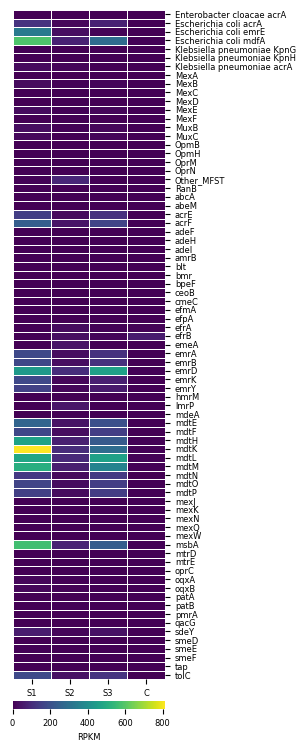

In [14]:
cm = 1/2.54
#multidrug heatmap
plt.rcParams['font.size'] = 6
plt.rcParams['font.family'] = 'Arial'

#create figure, one ax
fig, ax = plt.subplots(figsize=(5*cm, 24*cm))
#plot heatmap
sns.heatmap(multidrug_values, cmap="viridis", linewidths=.5, ax=ax, yticklabels=True,
            cbar_kws={'label': 'RPKM', 'orientation': 'horizontal', 'pad': 0.03, 'fraction': 0.05})
ax.set_ylabel('') #hide y label
#move ylabels to right
ax.yaxis.tick_right()
#rotate ylabels
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.savefig("./r-subplots/multidrug.svg", dpi=600, format='svg', bbox_inches='tight')
plt.savefig("./r-subplots/multidrug.pdf", dpi=600, format='svg', bbox_inches='tight')
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

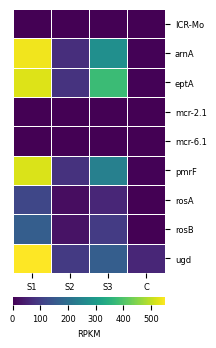

In [15]:
#polymyxin heatmap
#create figure, one ax
cm = 1/2.54
fig, ax = plt.subplots(figsize=(5*cm, 10*cm))
#plot heatmap
sns.heatmap(polymyxin_values, cmap="viridis", linewidths=.5, ax=ax, yticklabels=True,
            cbar_kws={'label': 'RPKM', 'orientation': 'horizontal', 'pad': 0.08, 'fraction': 0.05})
ax.set_ylabel('') #hide y label
#move ylabels to right
ax.yaxis.tick_right()
#rotate ylabels
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.savefig("polymyxin.svg", dpi=600, format='svg', bbox_inches='tight')
plt.show()